# Benchmark Comparison
This notebook loads the results from all YOLOv5, YOLOv7, and YOLOv8 experiments and generates comparison charts.

,model,fraction,map50,precision,recall
0,yolov5,0.1,0.849350,0.885940,0.798650
1,yolov7,0.1,0.008287,0.830700,0.042170
2,yolov8,0.1,0.906080,0.903132,0.824211


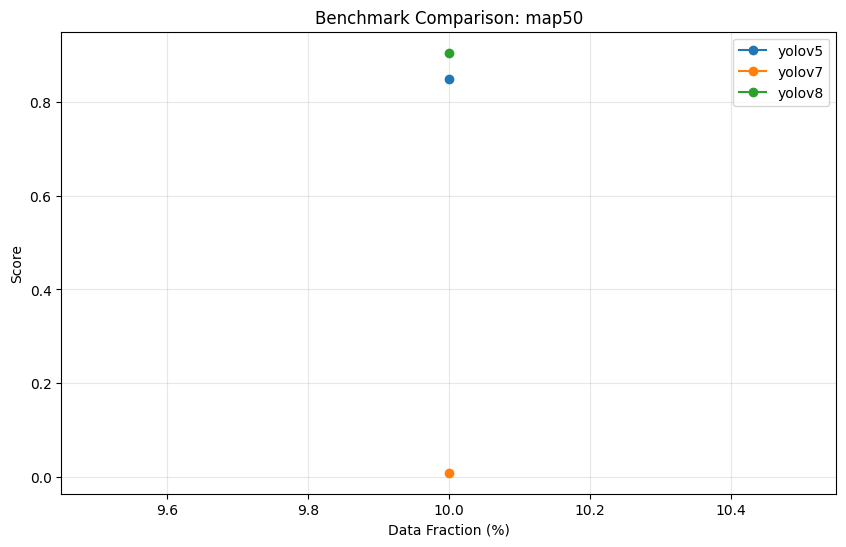

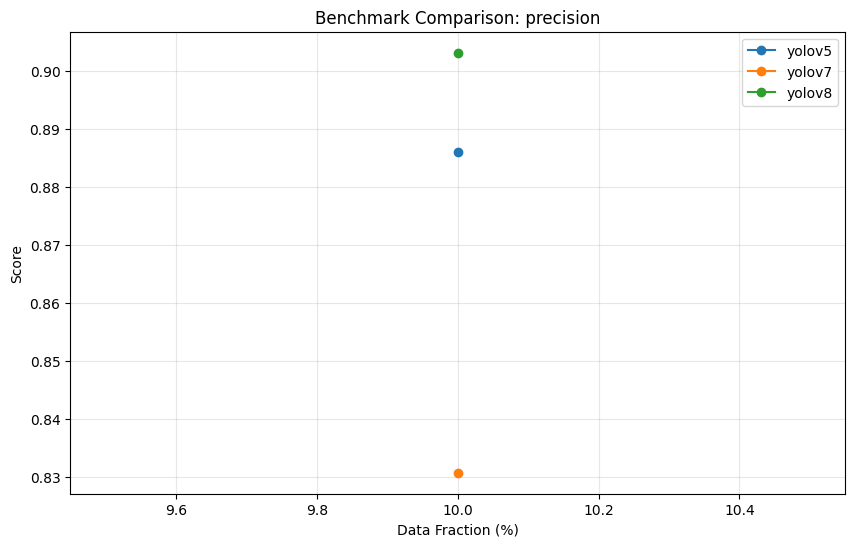

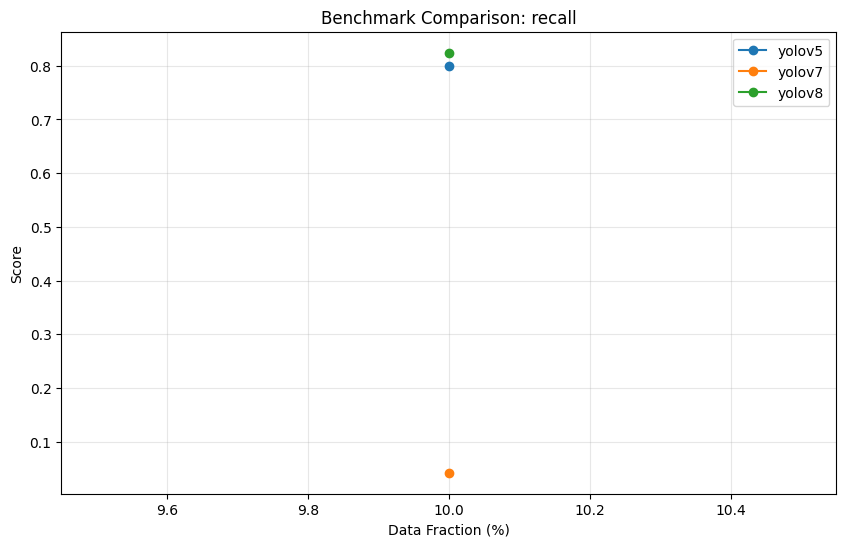

In [2]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

WORK_DIR = r"c:\Users\ahmad\Desktop\computer vision\weed_yolo_benchmark"
runs_dir = Path(WORK_DIR) / "runs"

def load_all_results():
    results = []
    # Scan for EXPERIMENT_DONE.json files
    for marker in runs_dir.glob("**/EXPERIMENT_DONE.json"):
        with open(marker, "r") as f:
            results.append(json.load(f))
    return pd.DataFrame(results)

df = load_all_results()
if df.empty:
    print("No results found yet. Run the training notebooks first!")
else:
    display(df.sort_values(["fraction", "model"]))
    
    # Plotting
    metrics = ["map50", "precision", "recall"]
    for metric in metrics:
        plt.figure(figsize=(10, 6))
        for model in df["model"].unique():
            sub = df[df["model"] == model].sort_values("fraction")
            plt.plot(sub["fraction"] * 100, sub[metric], marker='o', label=model)
        
        plt.title(f"Benchmark Comparison: {metric}")
        plt.xlabel("Data Fraction (%)")
        plt.ylabel("Score")
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.show()